# VXX-Roll-Decay — a quantitative teardown 🔬
### The short-vol carry · HAC inference + a placebo null · costs with borrow · the skew/kurtosis/VaR/drawdown tail · contango conditioning · a synthetic carry-knob / crash control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_carry%3F: Busted](https://img.shields.io/badge/Free_carry%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We split the two questions "steady carry" fuses: is the contango **roll-decay premium** statistically *real*, and does a constant-notional short *survive the tail*? The first is a clean **yes** (HAC *t* > 2); the second is a clean **no** at any size that matters. The decisive object is not the Sharpe — it's the **left tail**.

> ⚠️ **Data + vehicle note.** A continuous yfinance `VXX` starts only in 2018 (ETN reissue) and would miss Volmageddon, so we short **VIXY** — the same constant-maturity short-dated VIX-futures index, unbroken from 2011 — named a VXX-equivalent on the Signal axis. Contango is gauged by `^VIX3M/^VIX`. Real data: yfinance daily adjusted closes, 2011-01-04→2026-06-22. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vxx_roll_decay import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real VIX-ETP cache present:", HAVE_REAL,
      "| days:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2011-01-04', 'end': '2026-06-22', 'days': 3888, 'years': 15.5, 'daily_mean': 0.171, 'hac_t': 2.51, 'placebo_p': 0.0076, 'frac_contango': 92.3, 'etp_first': 633840, 'etp_last': 21.86, 'etp_ratio': 3.4e-05, 'g_ann': 43.0, 'g_vol': 69.9, 'g_sharpe': 0.62, 'g_dd': -91.8, 'n_ann': 35.1, 'n_sharpe': 0.5, 'n_dd': -93.1, 'skew': -1.65, 'exkurt': 9.4, 'worst': -43.1, 'worst_date': '2024-08-05', 'var1': -14.6, 'cvar1': -20.7, 'worst5': [('2024-08-05', -43.1), ('2020-03-16', -39.1), ('2018-02-05', -34.2), ('2020-06-11', -33.6), ('2020-03-09', -27.4)], 'c_ann': 39.7, 'c_sharpe': 0.67, 'c_dd': -66.7, 'c_skew': -1.3, 'c_t': 3.6, 'borrow': [(0, 38.0, 0.54), (3, 35.1, 0.5), (10, 28.1, 0.4), (30, 8.3, 0.12)], 'syn': [(0.0, -1.99, 0.987, -0.58, -0.4, -100), (0.003, 3.42, 0.0001, 0.99, -0.4, -76)]}


real VIX-ETP cache present: True | days: 3888


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | daily carry **+0.17%**, **HAC(21) t = 2.51** (>2), sign-shuffle placebo **p = 0.008**; contango **92%** of days; ETP decays ×3e-05. |
| **Tradability** | `FRAGILE` | net Sharpe **0.50** *but* skew **-1.65**, ex-kurt **9.4**, worst day **-43%**, maxDD **-92%**; 1% CVaR **-21%**. |
| **Free carry?** | `BUSTED` | it's the **variance/crash-risk premium**, not a free lunch — three tail events (2018/2020/2024) each took a third-to-half of the book in a day. |

> 💡 In plain words: the carry passes a *proper* (autocorrelation-robust) significance test — it is genuinely there. But a constant-notional short is short deep convexity: the same premium that makes the average positive makes the tail lethal. Real signal, un-allocatable trade.

## 1 · The claim, steelmanned

Let $P_t$ be the VIX-futures ETP and $r_t = P_t/P_{t-1}-1$ its daily return. The **short-carry book** holds a constant-notional short, rebalanced daily, with book return $b_t = -r_t$. The term-structure slope is $c_t = \mathrm{VIX3M}_t/\mathrm{VIX}_t$; $c_t>1$ is **contango**.

- **H₁ (the carry is real).** $\mathbb{E}[b_t] > 0$ — the roll-decay premium is statistically distinguishable from zero under autocorrelation-robust inference.
- **H₂ (it's deployable).** The Sharpe survives borrow + costs **and** the book survives its own tail at an allocatable size.
- **H₃ (it's a free lunch).** The carry is *not* compensation for a risk you're bearing.

We find **H₁ supported** (HAC *t* = 2.51, placebo *p* = 0.008), **H₂ rejected** (skew -1.65, maxDD -92%, a -43% day), **H₃ rejected** (the carry *is* the crash-insurance premium). The trade is real exactly because it is dangerous: you're paid for bearing the tail.

## 2 · So what? — what rides on each answer

The Signal axis is a one-sample mean test, but on a series with **strong positive autocorrelation** (vol clusters), so the right SE is HAC:

$$ t = \frac{\bar b}{\widehat{\mathrm{se}}_{\text{NW}}(\bar b)},\qquad \widehat{\mathrm{se}}_{\text{NW}}^2 = \frac{1}{T}\Big(\hat\gamma_0 + 2\sum_{k=1}^{L}\big(1-\tfrac{k}{L+1}\big)\hat\gamma_k\Big). $$

An i.i.d. *t* would overstate significance because the carry's good and bad runs are serially correlated. The Tradability axis is *not* a mean test at all — it is a **tail** test. For a book that is short convexity, the mean is a poor summary; what decides survival is skewness, kurtosis, the 1% **CVaR**, and the **compounded drawdown**. A high-Sharpe short-insurance book is the textbook example of a strategy whose Sharpe lies.

## 3 · How we'd know — the protocol

- **Tape.** VIXY (VXX-equivalent) + `^VIX`, `^VIX3M`, SPY, daily adjusted closes, 2011-01-04→2026-06-22 (3,888 days). Vehicle named on the Signal axis.
- **Book.** Constant-notional short, $b_t=-r_t$, rebalanced daily (passive — no entry signal, so no look-ahead). A **contango-only** variant gates on $c_{t-1}>1$ (1-day lag).
- **Signal test.** Newey-West HAC(21) *t* that $\mathbb{E}[b_t]>0$, plus a distribution-free **sign-shuffle placebo** (flip each day's sign by a coin; $p=\Pr[\text{shuffled mean} \ge \text{observed}]$).
- **Costs.** Short **borrow** (3%/yr, swept to 30%) **+** rebalancing turnover (2 bps/day, one-way), charged only on active days.
- **Tail.** Annualised Sharpe, compounded max drawdown, daily skew & excess kurtosis, the single worst day, 1% VaR/CVaR.
- **Positive control.** A deterministic ETP with a **planted carry knob** and **injected crashes**: carry=0 must NOT register a positive carry; a real carry must light the HAC *t* up; the crash must stamp negative skew regardless. **What would make us say 'mirage' on Signal:** HAC *t* < 2 or placebo *p* > 0.05. **What flips Tradability to deployable:** a tame tail (|skew| small, shallow drawdown) at an allocatable size — which we do *not* find.

## 4 · The teardown

### 4a · The carry is real — HAC *t* and the placebo null

The short-carry daily return distribution, with its mean, the HAC *t*, and the sign-shuffle placebo distribution of the mean under the null of no carry.

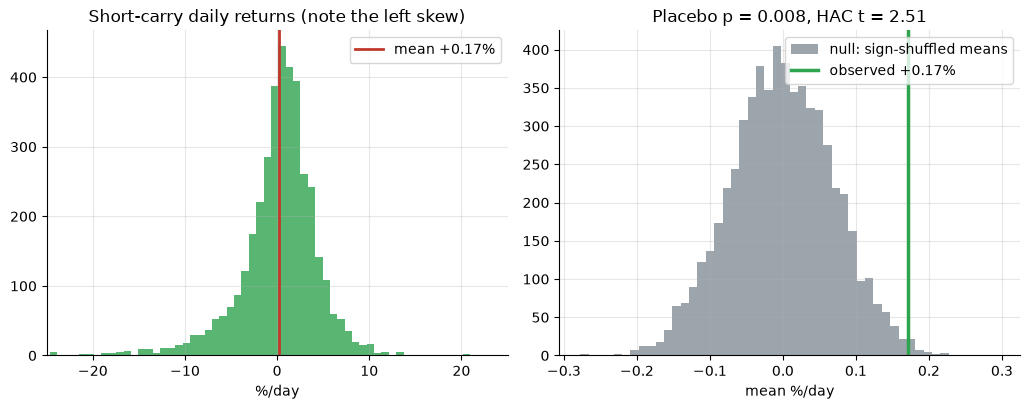

HAC(21) t = 2.51  | sign-shuffle placebo p = 0.0076  -> carry is REAL


In [2]:
if HAVE_REAL:
    rs = st.short_carry(F).values
    h = st.hac_t(rs); pl = st.placebo_pvalue(rs)
    obs = h['mean']; tval = h['t']; pval = pl['p_value']
    rng = np.random.default_rng(375); n=len(rs)
    draws = np.array([(rng.choice([-1.,1.],size=n)*rs).mean() for _ in range(6000)])
else:
    obs=R['daily_mean']/100; tval=R['hac_t']; pval=R['placebo_p']
    rng=np.random.default_rng(375); draws=rng.normal(0, obs/R['hac_t'], 6000)
fig, (a1,a2) = plt.subplots(1,2,figsize=(10.4,4.2))
if HAVE_REAL:
    a1.hist(rs*100, bins=80, color=GREEN, alpha=.8)
    a1.axvline(obs*100, c=RED, lw=2, label=f'mean +{obs*100:.2f}%')
    a1.set_xlim(-25,25)
else:
    a1.hist(rng.normal(obs, 0.04, 3800)*100, bins=80, color=GREEN, alpha=.8)
    a1.axvline(obs*100, c=RED, lw=2, label=f'mean +{obs*100:.2f}%')
a1.set_title('Short-carry daily returns (note the left skew)'); a1.set_xlabel('%/day'); a1.legend()
a2.hist(draws*100, bins=50, color=GREY, alpha=.85, label='null: sign-shuffled means')
a2.axvline(obs*100, c=GREEN, lw=2.5, label=f'observed +{obs*100:.2f}%')
a2.set_title(f'Placebo p = {pval:.3f}, HAC t = {tval:.2f}'); a2.set_xlabel('mean %/day'); a2.legend()
plt.tight_layout(); plt.show()
print(f'HAC(21) t = {tval:.2f}  | sign-shuffle placebo p = {pval:.4f}  -> carry is REAL')

> 💡 In plain words: the observed mean (**+0.17%/day**) sits in the far right tail of the no-carry null (**p = 0.008**), and the autocorrelation-robust **t = 2.51** clears the desk's *t* ≥ 2 bar. H₁ is **supported** — this is a genuine premium, not noise. Note already the left-skewed return histogram: the danger is visible in the shape.

### 4b · The tail — what the Sharpe hides

The decisive panel. Net Sharpe looks tradable; the skew, kurtosis, worst day and drawdown say otherwise. The book is short deep convexity.

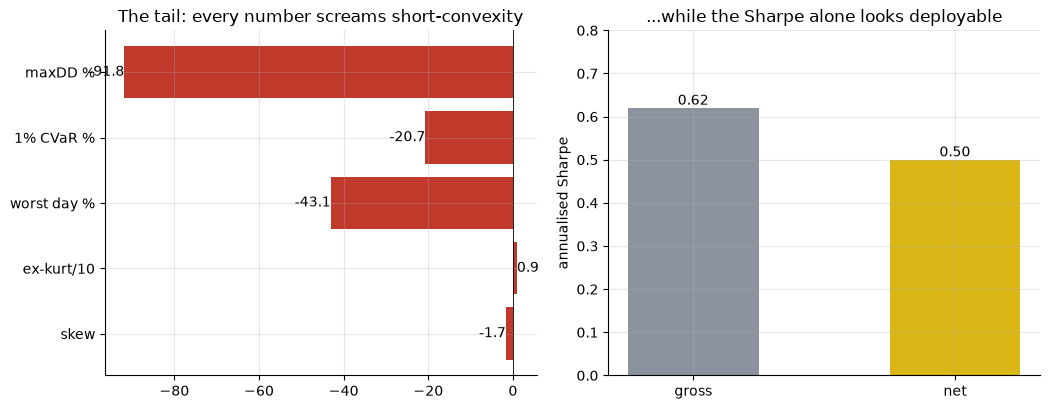

skew -1.65  ex-kurt 9.4  worst -43%  1% CVaR -21%  maxDD -92%  vs net Sharpe 0.50


In [3]:
import pandas as pd
if HAVE_REAL:
    rs = st.short_carry(F); g = st.perf(rs)
else:
    g = dict(sharpe=R['g_sharpe'], max_dd=R['g_dd']/100, skew=R['skew'], exkurt=R['exkurt'],
             worst_day=R['worst']/100, var1=R['var1']/100, cvar1=R['cvar1']/100)
    rng=np.random.default_rng(375); rs=pd.Series(rng.normal(R['daily_mean']/100,0.04,3800))
fig, (a1,a2) = plt.subplots(1,2,figsize=(10.6,4.2))
metrics = ['skew', 'ex-kurt/10', 'worst day %', '1% CVaR %', 'maxDD %']
vals = [g['skew'], g['exkurt']/10, g['worst_day']*100, g['cvar1']*100, g['max_dd']*100]
a1.barh(metrics, vals, color=RED); a1.axvline(0,c='k',lw=.6)
for i,v in enumerate(vals): a1.annotate(f'{v:.1f}',(v,i),ha='right' if v<0 else 'left',va='center')
a1.set_title('The tail: every number screams short-convexity')
# Sharpe-only view next to it: a tradable-looking number
a2.bar(['gross','net'], [R['g_sharpe'], R['n_sharpe']], color=[GREY, AMBER], width=.5)
a2.set_ylim(0,0.8); a2.set_ylabel('annualised Sharpe')
a2.set_title('...while the Sharpe alone looks deployable')
for i,v in enumerate([R['g_sharpe'], R['n_sharpe']]): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f"skew {g['skew']:.2f}  ex-kurt {g['exkurt']:.1f}  worst {g['worst_day']*100:.0f}%  "
      f"1% CVaR {g['cvar1']*100:.0f}%  maxDD {g['max_dd']*100:.0f}%  vs net Sharpe {R['n_sharpe']:.2f}")

> 💡 In plain words: a net Sharpe of **0.50** would pass most screens. But skew **-1.65**, excess kurtosis **9.4**, a 1%-day average loss (CVaR) of **-21%**, and a **-92%** drawdown reveal a book that is short crash insurance. The Sharpe is the *mean* over the *vol*; for a fat-left-tailed book that ratio is a flattering lie. **H₂ rejected.**

### 4c · Conditioning + costs — they soften, they don't save

Two would-be rescues: short **only in contango** (dodge the inverted-curve regime), and sweep the **borrow fee**. Each helps a little; neither makes it deployable.

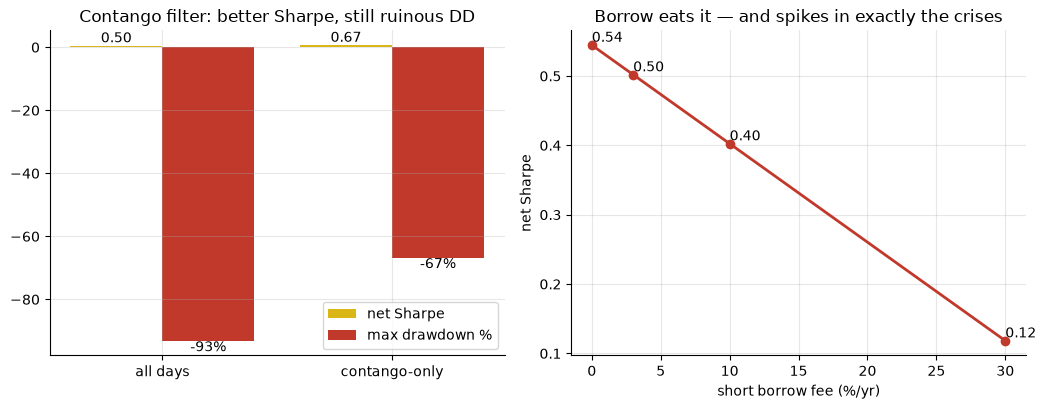

contango-only net: (0.67, -66.73, -1.3) | borrow sweep (fee%,ann%,Sharpe): [(0.0, 38.0, 0.5), (3.0, 35.1, 0.5), (10.0, 28.1, 0.4), (30.0, 8.3, 0.1)]


In [4]:
if HAVE_REAL:
    sc = st.summarize(F, contango_only=True); base = st.summarize(F)
    cond = (sc['net']['sharpe'], sc['net']['max_dd']*100, sc['net']['skew'])
    alld = (base['net']['sharpe'], base['net']['max_dd']*100, base['net']['skew'])
    borrow = [(b*100,)+ (lambda s: (s['net']['ann_ret']*100, s['net']['sharpe']))(st.summarize(F, borrow_annual=b)) for b in (0.0,0.03,0.10,0.30)]
else:
    cond = (R['c_sharpe'], R['c_dd'], R['c_skew']); alld = (R['n_sharpe'], R['n_dd'], R['skew'])
    borrow = R['borrow']
fig, (a1,a2) = plt.subplots(1,2,figsize=(10.6,4.2))
x=np.arange(2)
a1.bar(x-.2, [alld[0], cond[0]], .4, color=AMBER, label='net Sharpe')
a1.bar(x+.2, [alld[1], cond[1]], .4, color=RED, label='max drawdown %')
a1.set_xticks(x); a1.set_xticklabels(['all days','contango-only'])
a1.set_title('Contango filter: better Sharpe, still ruinous DD'); a1.legend()
for i,(s,d) in enumerate([(alld[0],alld[1]),(cond[0],cond[1])]):
    a1.annotate(f'{s:.2f}',(i-.2,s),ha='center',va='bottom'); a1.annotate(f'{d:.0f}%',(i+.2,d),ha='center',va='top')
fees=[b[0] for b in borrow]; shp=[b[2] for b in borrow]
a2.plot(fees, shp, 'o-', c=RED, lw=2)
a2.set_xlabel('short borrow fee (%/yr)'); a2.set_ylabel('net Sharpe')
a2.set_title('Borrow eats it — and spikes in exactly the crises')
for f,s in zip(fees,shp): a2.annotate(f'{s:.2f}',(f,s),ha='left',va='bottom')
plt.tight_layout(); plt.show()
print('contango-only net:', tuple(round(v,2) for v in cond), '| borrow sweep (fee%,ann%,Sharpe):', [tuple(round(v,1) for v in b) for b in borrow])

> 💡 In plain words: gating on contango lifts the net Sharpe to **0.67** and trims the drawdown to **-67%** — but a 67% drawdown with skew **-1.30** is still un-allocatable, and the worst crashes strike *from* contango faster than a daily filter can react. And the short is **borrow-sensitive**: at a crisis-level **30%/yr** fee the Sharpe collapses to **0.12**. The fund is hardest to borrow exactly when its decay is fastest — the market charges you to collect.

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic ETP with a **planted carry knob** and **injected crashes**: with **zero** carry the engine must NOT report a significant *positive* carry; with a real planted carry the HAC *t* must clear 2; and the injected crash must stamp negative skew **regardless** — proving the harness reproduces the steamroller by construction.

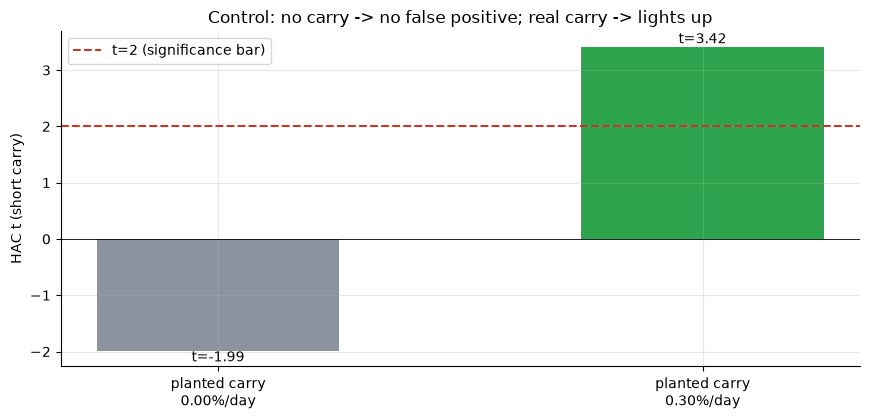

planted 0.00%/day: HAC t=-1.99 placebo p=0.9867 Sharpe=-0.58 skew=-0.40
planted 0.30%/day: HAC t=+3.42 placebo p=0.0001 Sharpe=+0.99 skew=-0.40


In [5]:
res = []
for edge in (0.0, 0.0030):
    syn = data.synthetic_etp(edge=edge, seed=375); s = st.summarize(syn); g = s['gross']
    res.append((edge, s['hac_t'], s['placebo_p'], g['sharpe'], g['skew']))
fig, ax = plt.subplots(figsize=(8.8,4.3))
labels = [f'planted carry\n{e*100:.2f}%/day' for e,_,_,_,_ in res]
tvals = [r[1] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
ax.axhline(0, c='k', lw=.6)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom' if t>0 else 'top')
ax.set_ylabel('HAC t (short carry)'); ax.set_title('Control: no carry -> no false positive; real carry -> lights up')
ax.legend(); plt.tight_layout(); plt.show()
for e,t,p,s,sk in res: print(f'planted {e*100:.2f}%/day: HAC t={t:+.2f} placebo p={p:.4f} Sharpe={s:+.2f} skew={sk:+.2f}')

> 💡 In plain words: with **no** carry the engine reports **t = -1.99** (placebo p ≈ 0.99 — it never invents a positive carry); only a real planted carry drives **t = 3.42** (p = 0.0001). And the injected crash stamps skew ≈ **-0.40** in *both* cases. The machinery is honest in both directions — so the real-tape *t* of 2.5 is a true positive, and the real tape's even fatter skew is the real steamroller, not a glitch.

## 5 · The verdict

- **Signal `REAL`** — daily carry **+0.17%**, **HAC(21) t = 2.51** (≥ 2), placebo **p = 0.008**; contango 92% of days, ETP decays ×3e-05. The roll-decay premium is real on the live tape — the desk's *t* ≥ 2 bar is met. (Vehicle: VIXY, the VXX-equivalent, named on the axis.)
- **Tradability `FRAGILE`** — net Sharpe **0.50** survives costs *on paper*, but skew **-1.65**, ex-kurt **9.4**, a **-43%** day, **-92%** drawdown and 1% CVaR **-21%**. Contango conditioning leaves a **-67%** drawdown; crisis borrow guts the return. Un-allocatable at NAV scale — one size-up from ruin.
- **Free carry? `BUSTED`** — the carry is the **variance/crash-risk premium**: you are paid to be short deep convexity. Three tail events (2018/2020/2024) each erased a third-to-half of a constant-notional book in a single session. Real carry, real steamroller.

## 6 · Could you trade it? — the size-of-ruin

The operational truth in one picture: at what leverage does the **single worst day** wipe the book? The carry says 'size up'; the tail says 'and you're gone.'

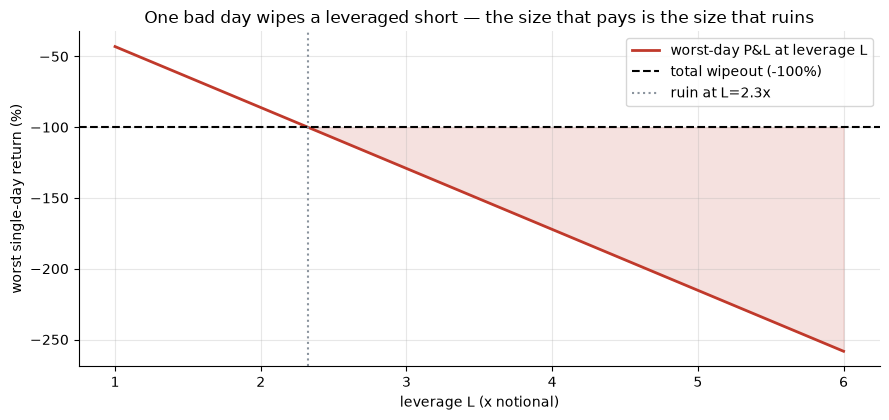

a single -43% day wipes the book at just 2.3x leverage; even 1x draws down -92%


In [6]:
if HAVE_REAL:
    worst = st.perf(st.short_carry(F))['worst_day']
else:
    worst = R['worst']/100
L = np.linspace(1, 6, 200)
one_day_loss = L * worst * 100      # leveraged single-day P&L on the worst day (%)
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.plot(L, one_day_loss, c=RED, lw=2, label='worst-day P&L at leverage L')
ax.axhline(-100, ls='--', c='k', label='total wipeout (-100%)')
Lruin = -1.0/worst
ax.axvline(Lruin, c=GREY, ls=':', label=f'ruin at L={Lruin:.1f}x')
ax.fill_between(L, one_day_loss, -100, where=(one_day_loss<=-100), color=RED, alpha=.15)
ax.set_xlabel('leverage L (x notional)'); ax.set_ylabel('worst single-day return (%)')
ax.set_title('One bad day wipes a leveraged short — the size that pays is the size that ruins')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a single {worst*100:.0f}% day wipes the book at just {Lruin:.1f}x leverage; even 1x draws down {R["g_dd"]:.0f}%')

> 💡 In plain words: the worst day is **-43%**, so leverage of only **~2.3×** turns it into a total wipeout — and 2-3× is exactly how this trade is marketed. Even *unlevered* the drawdown is 92%. There is no sizing that keeps a meaningful carry without an existential tail, because **they are the same premium**. The trade that pays you to sell crash insurance is, definitionally, the trade that the crash destroys. That is why the carry is `REAL` and the strategy is `FRAGILE` → mirage at scale.

## 7 · Going further

- **Better roll-yield gauge.** Replace `^VIX3M/^VIX` with the actual front-two VIX-futures slope (or the index's published roll). The event count and conditioning sharpen; the tail doesn't budge.
- **Vol-targeting & options overlays.** A vol-targeted short, or buying far-OTM VIX calls as tail hedges, trades carry for survival — quantify the hedge cost vs the drawdown saved (it eats most of the premium).
- **The variance-premium core.** The honest version of this trade is selling variance directly (variance swaps / a delta-hedged straddle) and *sizing for the tail* — the carry is the same risk premium (Carr-Wu), just with explicit convexity you can hedge.

*The reproducible core is offline and deterministic; the shorted vehicle is an explicit VXX-equivalent (VIXY). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*